1. Загружаем train.csv и test.csv.

2. Проверка структуры данных: колонки, размер, пропуски.

3. Проверка баланса классов по колонке genre.

4. Создание текстового признака full_text из названия фильма и описания.

5. Кодирование жанра из строк в числовые метки через LabelEncoder.

6. Деление train.csv на train / validation / test с stratify, чтобы сохранить баланс жанров.

7. Для LSTM:
токенизируем тексты;
строим словарь слов;
переводим тексты в последовательности индексов;
обрезаем или дополняем последовательности до одинаковой длины;
создаем Dataset и DataLoader;
строим модель Embedding -> LSTM -> Linear;
обучаем модель;
считаем accuracy, precision, recall, F1;
строим матрицу ошибок.

8. Для DistilBERT:
загружаем DistilBertTokenizer;
токенизируем тексты через tokenizer;
создаем Dataset и DataLoader;
загружаем DistilBertForSequenceClassification на 27 классов;
обучаем или дообучаем модель;
считаем те же метрики;
строим матрицу ошибок.

9. Сравнить LSTM и DistilBERT.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df_test = pd.read_csv('test.csv')
df_test

,name,text
0,Edgar's Lunch (1998),"L.R. Brane loves his life - his car, his apar..."
1,La guerra de papá (1977),"Spain, March 1964: Quico is a very naughty ch..."
2,Off the Beaten Track (2010),One year in the life of Albin and his family ...
3,Meu Amigo Hindu (2015),"His father has died, he hasn't spoken with hi..."
4,Er nu zhai (1955),Before he was known internationally as a mart...
...,...,...
54195,"""Tales of Light & Dark"" (2013)","Covering multiple genres, Tales of Light & Da..."
54196,Der letzte Mohikaner (1965),As Alice and Cora Munro attempt to find their...
54197,Oliver Twink (2007),A movie 169 years in the making. Oliver Twist...
54198,Slipstream (1973),"Popular, but mysterious rock D.J Mike Mallard..."


In [3]:
df_train = pd.read_csv('train.csv')
df_train

,name,genre,text
0,Oscar et la dame rose (2009),drama,Listening in to a conversation between his do...
1,Cupid (1997),thriller,A brother and sister with a past incestuous r...
2,"Young, Wild and Wonderful (1980)",adult,As the bus empties the students for their fie...
3,The Secret Sin (1915),drama,To help their unemployed father make ends mee...
4,The Unrecovered (2007),drama,The film's title refers not only to the un-re...
...,...,...,...
54209,"""Bonino"" (1953)",comedy,This short-lived NBC live sitcom centered on ...
54210,Dead Girls Don't Cry (????),horror,The NEXT Generation of EXPLOITATION. The sist...
54211,Ronald Goedemondt: Ze bestaan echt (2008),documentary,"Ze bestaan echt, is a stand-up comedy about g..."
54212,Make Your Own Bed (1944),comedy,Walter and Vivian live in the country and hav...


In [4]:
df_test.isnull().sum()

name    0
text    0
dtype: int64

In [5]:
df_train.isnull().sum()

name     0
genre    0
text     0
dtype: int64

In [6]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54200 entries, 0 to 54199
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   name    54200 non-null  object
 1   text    54200 non-null  object
dtypes: object(2)
memory usage: 847.0+ KB


In [7]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54214 entries, 0 to 54213
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   name    54214 non-null  object
 1   genre   54214 non-null  object
 2   text    54214 non-null  object
dtypes: object(3)
memory usage: 1.2+ MB


In [8]:
# в признаки кладем только то, что реально известно на входе: название фильма и описание сюжета. genre оставляем как целевую переменную для обучения
df_train['full_text'] = df_train['name'] + ' ' + df_train['text']
df_test['full_text'] = df_test['name'] + ' ' + df_test['text']

In [9]:
df_train[['name', 'text', 'genre', 'full_text']].head()

,name,text,genre,full_text
0,Oscar et la dame rose (2009),Listening in to a conversation between his do...,drama,Oscar et la dame rose (2009) Listening in t...
1,Cupid (1997),A brother and sister with a past incestuous r...,thriller,Cupid (1997) A brother and sister with a pa...
2,"Young, Wild and Wonderful (1980)",As the bus empties the students for their fie...,adult,"Young, Wild and Wonderful (1980) As the bus..."
3,The Secret Sin (1915),To help their unemployed father make ends mee...,drama,The Secret Sin (1915) To help their unemplo...
4,The Unrecovered (2007),The film's title refers not only to the un-re...,drama,The Unrecovered (2007) The film's title ref...


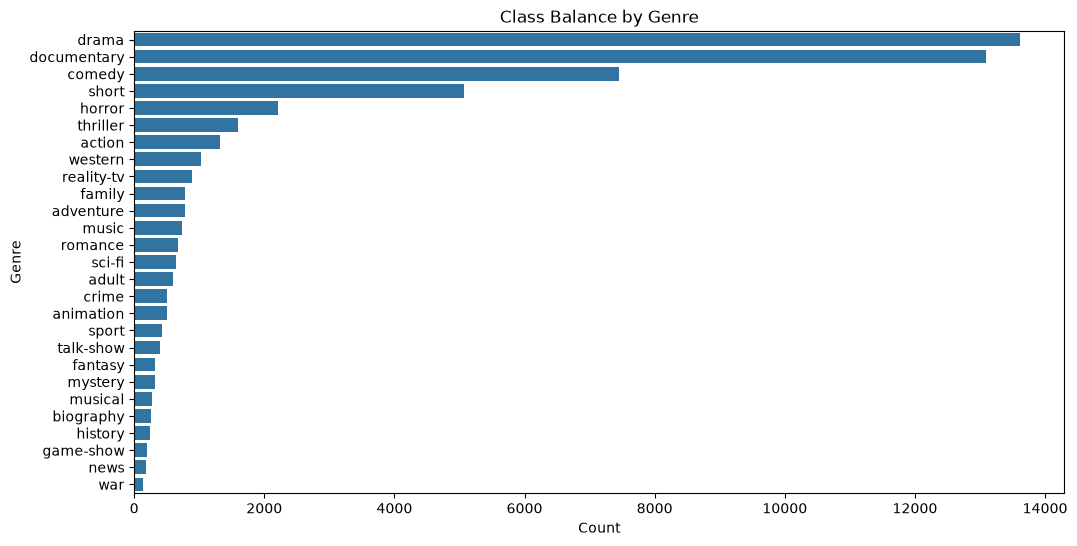

In [10]:
plt.figure(figsize=(12, 6))

sns.countplot(
    data=df_train,
    y='genre',
    order=df_train['genre'].value_counts().index
)

plt.title('Class Balance by Genre')
plt.xlabel('Count')
plt.ylabel('Genre')
plt.show()

In [11]:
genre_share = df_train['genre'].value_counts(normalize=True)
genre_share

genre
drama          0.251098
documentary    0.241561
comedy         0.137363
short          0.093574
horror         0.040654
thriller       0.029347
action         0.024256
western        0.019036
reality-tv     0.016306
family         0.014461
adventure      0.014295
music          0.013484
romance        0.012395
sci-fi         0.011934
adult          0.010883
crime          0.009315
animation      0.009186
sport          0.007968
talk-show      0.007212
fantasy        0.005958
mystery        0.005884
musical        0.005109
biography      0.004888
history        0.004482
game-show      0.003578
news           0.003339
war            0.002435
Name: proportion, dtype: float64

В датасете 27 жанров, при этом классы сильно несбалансированы. 
Самые частые жанры — drama, documentary, comedy и short. 
Они занимают большую часть выборки: drama около 25%, documentary около 24%, comedy около 14%, short около 9%.
Редкие классы, например war, news, game-show, history, biography, представлены менее чем 0.5% каждый.

Из-за такого дисбаланса accuracy может быть не очень показательной метрикой- нужно будет смотреть не только accuracy, но и precision, recall, F1-score, особенно macro F1 и weighted F1.

In [12]:
# Кодируем жанры из строк в числовые метки через LabelEncoder
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

df_train['label'] = label_encoder.fit_transform(df_train['genre'])

num_classes = df_train['label'].nunique()

print('Количество классов:', num_classes)
print('Классы:', label_encoder.classes_)

Количество классов: 27
Классы: ['action' 'adult' 'adventure' 'animation' 'biography' 'comedy' 'crime'
 'documentary' 'drama' 'family' 'fantasy' 'game-show' 'history' 'horror'
 'music' 'musical' 'mystery' 'news' 'reality-tv' 'romance' 'sci-fi'
 'short' 'sport' 'talk-show' 'thriller' 'war' 'western']


In [13]:
df_train[['genre', 'label']].head(10)

,genre,label
0,drama,8
1,thriller,24
2,adult,1
3,drama,8
4,drama,8
5,documentary,7
6,comedy,5
7,crime,6
8,reality-tv,18
9,horror,13


делим df_train на train / validation / test с stratify=df_train['label'].

Так как исходный test.csv без genre, его нельзя использовать для расчета метрик. Поэтому из train.csv делаем три части:

train      — обучение моделей;
validation — контроль качества во время обучения;
test       — финальная честная оценка.

In [14]:
# делим 70 / 15 / 15
from sklearn.model_selection import train_test_split

# Сначала отделяем финальную test-часть: 15% от всего train.csv
train_val_df, test_df_labeled = train_test_split(
    df_train,
    test_size=0.15,
    random_state=42,
    stratify=df_train['label']
)

# Затем из оставшихся 85% отделяем validation
# 0.1765 от 85% примерно дает 15% от исходного датасета
train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.1765,
    random_state=42,
    stratify=train_val_df['label']
)

print('Train size:', train_df.shape)
print('Validation size:', val_df.shape)
print('Test size:', test_df_labeled.shape)

Train size: (37947, 5)
Validation size: (8134, 5)
Test size: (8133, 5)


Данные были разделены на обучающую, валидационную и тестовую выборки в соотношении примерно 70/15/15. 
Разбиение выполнено со stratify по целевой переменной label, чтобы сохранить исходные пропорции жанров во всех частях выборки. 
Это важно из-за выраженного дисбаланса классов.

### LSTM

In [15]:
# 1. Токенизация
import re
from collections import Counter

def tokenize(text):
    # Функция принимает один текст и возвращает список токенов
    text = str(text).lower()
    # Заменяем все символы, кроме английских букв, цифр и пробелов, на пробелы
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    tokens = text.split()
    return tokens

In [16]:
# Создаем словарь
# Ограничиваем максимальный размер словаря
# Это нужно, чтобы не хранить слишком много редких слов
MAX_VOCAB_SIZE = 30000
# Минимальная частота слова для попадания в словарь
MIN_FREQ = 2
# Создаем счетчик слов
counter = Counter()
# Проходим только по обучающей выборке
# словарь строим не на validation/test, чтобы не было утечки данных
for text in train_df['full_text']:
    counter.update(tokenize(text))
# Берем самые частые слова
# Минус 2, т.к. два места зарезервированы под <PAD> и <UNK>
most_common_words = counter.most_common(MAX_VOCAB_SIZE - 2)
# Создаем словарь token -> index
# <PAD> используется для дополнения коротких текстов
# <UNK> используется для неизвестных слов
word_to_idx = {
    '<PAD>': 0,
    '<UNK>': 1
}
# Проходим по самым частым словам и их частотам
for word, freq in most_common_words:
    # Добавляем слово только если оно встретилось не реже MIN_FREQ раз
    if freq >= MIN_FREQ:
        # Присваиваем слову следующий свободный индекс
        word_to_idx[word] = len(word_to_idx)
# Сохраняем итоговый размер словаря
vocab_size = len(word_to_idx)

print('Vocab size:', vocab_size)

Vocab size: 30000


In [17]:
# Перевод текста в индексы

# Максимальная длина последовательности
# Более длинные тексты будут обрезаться, короткие дополняться нулями
MAX_LEN = 128
# Функция переводит один текст в список числовых индексов одинаковой длины
def text_to_sequence(text, word_to_idx, max_len=MAX_LEN):
    # Разбиваем текст на токены
    tokens = tokenize(text)
    # Для каждого токена берем его индекс из словаря
    # Если токена нет в словаре, используем индекс <UNK>
    sequence = [
        word_to_idx.get(token, word_to_idx['<UNK>'])
        for token in tokens
    ]
    # Обрезаем последовательность до max_len, если текст слишком длинный
    sequence = sequence[:max_len]
    # Если последовательность короче max_len
    if len(sequence) < max_len:
        # дополняем ее токенами <PAD> до нужной длины
        sequence += [word_to_idx['<PAD>']] * (max_len - len(sequence))
    # Возвращаем последовательность индексов
    return sequence

In [18]:
# Dataset
import torch
from torch.utils.data import Dataset, DataLoader
# Dataset нужен для описания логики получения одного объекта
# DataLoader нужен для формирования батчей

# Создаем собственный Dataset для текстов и жанров фильмов
class MovieGenreDataset(Dataset):
    # Конструктор получает датафрейм, словарь и максимальную длину текста
    def __init__(self, dataframe, word_to_idx, max_len=MAX_LEN):
        # Сохраняем тексты
        self.texts = dataframe['full_text'].values
        # Сохраняем числовые метки жанров
        self.labels = dataframe['label'].values
        # Сохраняем словарь token -> index
        self.word_to_idx = word_to_idx
        # Сохраняем максимальную длину последовательности
        self.max_len = max_len
    # Метод возвращает количество объектов в датасете
    def __len__(self):
        return len(self.texts)
    # Метод возвращает один объект по индексу idx
    def __getitem__(self, idx):
        # Берем текст по индексу и переводим его в последовательность индексов
        sequence = text_to_sequence(
            self.texts[idx],
            self.word_to_idx,
            self.max_len
        )
        # Берем соответствующую метку жанра
        label = self.labels[idx]
        # Возвращаем словарь:
        # input_ids — числовая последовательность текста;
        # label — правильный класс
        return {
            'input_ids': torch.tensor(sequence, dtype=torch.long),
            'label': torch.tensor(label, dtype=torch.long)
        }

In [19]:
# Dataloader
BATCH_SIZE = 64
# Создаем Dataset для обучающей выборки
train_dataset_lstm = MovieGenreDataset(train_df, word_to_idx)
# Создаем Dataset для валидационной выборки
val_dataset_lstm = MovieGenreDataset(val_df, word_to_idx)
# Создаем Dataset для тестовой выборки
test_dataset_lstm = MovieGenreDataset(test_df_labeled, word_to_idx)
# DataLoader для обучения
# shuffle=True перемешивает объекты перед каждой эпохой
train_loader_lstm = DataLoader(
    train_dataset_lstm,
    batch_size=BATCH_SIZE,
    shuffle=True
)
# DataLoader для validation
# Перемешивание не нужно, т.к. мы только оцениваем модель
val_loader_lstm = DataLoader(
    val_dataset_lstm,
    batch_size=BATCH_SIZE,
    shuffle=False
)
# DataLoader для test.Также без перемешивания
test_loader_lstm = DataLoader(
    test_dataset_lstm,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [20]:
# LSTM mnodel
import torch.nn as nn
# Описываем класс модели для классификации текста
class LSTMClassifier(nn.Module):
    # Конструктор модели получает параметры архитектуры
    def __init__(
        self,
        vocab_size,
        embedding_dim,
        hidden_dim,
        output_dim,
        num_layers=1,
        dropout=0.3
    ):
        # Инициализируем родительский класс nn.Module
        super(LSTMClassifier, self).__init__()
        # Embedding-слой переводит индексы слов в плотные векторы
        # padding_idx=0 означает, что токен <PAD> не будет обучаться как обычное слово
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=0
        )
        # LSTM обрабатывает последовательность векторов слов
        # input_size — размер embedding-вектора
        # hidden_size — размер скрытого состояния LSTM
        # batch_first=True означает формат входа: batch, sequence_length, features.
        # dropout внутри LSTM работает только если num_layers > 1
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        # Dropout случайно отключает часть нейронов во время обучения
        # Это помогает уменьшить переобучение
        self.dropout = nn.Dropout(dropout)
        # Полносвязный слой переводит скрытое состояние LSTM в logits по числу классов
        self.fc = nn.Linear(hidden_dim, output_dim)
    # Метод forward описывает прямой проход модели
    def forward(self, input_ids):
        # Переводим индексы слов в embedding-векторы
        embedded = self.embedding(input_ids)
        # Пропускаем последовательность через LSTM
        # lstm_output содержит выходы для всех токенов
        # hidden содержит последние скрытые состояния
        lstm_output, (hidden, cell) = self.lstm(embedded)
        # Берем последнее скрытое состояние последнего слоя LSTM
        # Оно используется как представление всего текста
        last_hidden = hidden[-1]
        # Применяем dropout перед классификатором
        dropped = self.dropout(last_hidden)
        # Получаем сырые предсказания модели для каждого жанра
        logits = self.fc(dropped)

        return logits

In [21]:
# Создаем модель
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# Создаем LSTM-модель и переносим ее на выбранное устройство
lstm_model = LSTMClassifier(
    vocab_size=vocab_size,
    embedding_dim=128,
    hidden_dim=128,
    output_dim=num_classes,
    num_layers=1,
    dropout=0.3
).to(device)
# Функция потерь для многоклассовой классификации
# Подходит, когда классы представлены числами 0, 1, 2, ...
criterion = nn.CrossEntropyLoss()
# Оптимизатор Adam будет обновлять веса модели
# lr=1e-3 — скорость обучения
optimizer = torch.optim.Adam(
    lstm_model.parameters(),
    lr=1e-3
)

print(lstm_model)

LSTMClassifier(
  (embedding): Embedding(30000, 128, padding_idx=0)
  (lstm): LSTM(128, 128, batch_first=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=27, bias=True)
)


In [22]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    # Функция обучает модель одну эпоху на train-выборке

    model.train()
    # Переводим модель в режим обучения
    # В этом режиме работают dropout, batch norm и считается градиент

    total_loss = 0
    # Здесь будем накапливать loss по всем батчам

    correct = 0
    # Здесь будем считать количество правильных ответов

    total = 0
    # Здесь будем считать общее количество объектов

    for batch in dataloader:
        # Проходим по батчам из DataLoader

        input_ids = batch['input_ids'].to(device)
        # Берем последовательности токенов и переносим их на CPU/GPU

        labels = batch['label'].to(device)
        # Берем правильные метки классов и переносим их на CPU/GPU

        optimizer.zero_grad()
        # Обнуляем градиенты с предыдущего шага обучения

        outputs = model(input_ids)
        # Прогоняем входные данные через модель
        # На выходе получаем logits по каждому классу

        loss = criterion(outputs, labels)
        # Считаем ошибку между предсказаниями модели и правильными метками.

        loss.backward()
        # Выполняем обратное распространение ошибки
        # PyTorch считает градиенты для обучаемых параметров

        optimizer.step()
        # Обновляем веса модели на основе рассчитанных градиентов

        total_loss += loss.item()
        # Добавляем значение loss текущего батча к общей сумме

        _, preds = torch.max(outputs, dim=1)
        # Выбираем класс с максимальным значением logit
        # Это итоговое предсказание модели

        correct += (preds == labels).sum().item()
        # Считаем, сколько предсказаний в батче совпало с правильными метками

        total += labels.size(0)
        # Добавляем размер батча к общему количеству объектов

    avg_loss = total_loss / len(dataloader)
    # Считаем средний loss за эпоху

    accuracy = correct / total
    # Считаем accuracy за эпоху

    return avg_loss, accuracy
    # Возвращаем средний loss и accuracy

In [23]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
# Импортируем метрики качества классификации

def evaluate_lstm(model, dataloader, criterion, device):
    # Функция оценивает модель на validation или test-выборке

    model.eval()
    # Переводим модель в режим оценки
    # Dropout отключается, веса модели не обновляются

    total_loss = 0
    # будем накапливать loss по всем батчам

    all_labels = []
    # Список для всех истинных меток

    all_preds = []
    # Список для всех предсказанных классов

    all_probs = []
    # Список для вероятностей по классам
    # Может пригодиться для дальнейшего анализа

    with torch.no_grad():
        # Отключаем расчет градиентов
        # Это ускоряет оценку и экономит память

        for batch in dataloader:
            # Проходим по батчам validation или test

            input_ids = batch['input_ids'].to(device)
            # Переносим входные последовательности на CPU/GPU

            labels = batch['label'].to(device)
            # Переносим правильные метки на CPU/GPU

            outputs = model(input_ids)
            # Получаем logits модели по каждому классу

            loss = criterion(outputs, labels)
            # Считаем loss на текущем батче

            probs = torch.softmax(outputs, dim=1)
            # Преобразуем logits в вероятности классов

            _, preds = torch.max(outputs, dim=1)
            # Выбираем класс с максимальным logit как предсказание

            total_loss += loss.item()
            # Добавляем loss батча к общей сумме

            all_labels.extend(labels.cpu().numpy())
            # Переносим истинные метки на CPU и добавляем в общий список

            all_preds.extend(preds.cpu().numpy())
            # Переносим предсказания на CPU и добавляем в общий список

            all_probs.extend(probs.cpu().numpy())
            # Переносим вероятности на CPU и добавляем в общий список

    avg_loss = total_loss / len(dataloader)
    # Считаем средний loss по всем батчам

    accuracy = accuracy_score(all_labels, all_preds)
    # Считаем долю правильных предсказаний

    precision = precision_score(
        all_labels,
        all_preds,
        average='weighted',
        zero_division=0
    )
    # Считаем weighted precision
    # weighted учитывает размер каждого класса

    recall = recall_score(
        all_labels,
        all_preds,
        average='weighted',
        zero_division=0
    )
    # Считаем weighted recall

    f1_weighted = f1_score(
        all_labels,
        all_preds,
        average='weighted',
        zero_division=0
    )
    # Считаем weighted F1

    f1_macro = f1_score(
        all_labels,
        all_preds,
        average='macro',
        zero_division=0
    )
    # Считаем macro F1
    # Она усредняет качество по классам без учета их размера

    return {
        'loss': avg_loss,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_weighted': f1_weighted,
        'f1_macro': f1_macro,
        'labels': all_labels,
        'preds': all_preds,
        'probs': all_probs
    }
    # Возвращаем словарь со всеми метриками и предсказаниями

In [24]:
NUM_EPOCHS = 5
# Количество эпох обучения

train_losses = []
# Сюда будем сохранять train loss по эпохам

val_losses = []
# Сюда будем сохранять validation loss по эпохам

train_accuracies = []
# Сюда будем сохранять train accuracy по эпохам

val_accuracies = []
# Сюда будем сохранять validation accuracy по эпохам

best_val_f1 = 0
# Здесь храним лучшее значение F1 на validation

best_lstm_state = None
# Здесь сохраним веса лучшей версии модели

for epoch in range(NUM_EPOCHS):
    # Запускаем цикл обучения по эпохам

    train_loss, train_accuracy = train_one_epoch(
        lstm_model,
        train_loader_lstm,
        criterion,
        optimizer,
        device
    )
    # Обучаем модель одну эпоху и получаем train loss и train accuracy

    val_metrics = evaluate_lstm(
        lstm_model,
        val_loader_lstm,
        criterion,
        device
    )
    # Оцениваем модель на validation после эпохи

    train_losses.append(train_loss)
    # Сохраняем train loss текущей эпохи

    val_losses.append(val_metrics['loss'])
    # Сохраняем validation loss текущей эпохи

    train_accuracies.append(train_accuracy)
    # Сохраняем train accuracy текущей эпохи

    val_accuracies.append(val_metrics['accuracy'])
    # Сохраняем validation accuracy текущей эпохи

    print(
        f"Epoch [{epoch + 1}/{NUM_EPOCHS}] | "
        f"Train loss: {train_loss:.4f} | "
        f"Train acc: {train_accuracy:.4f} | "
        f"Val loss: {val_metrics['loss']:.4f} | "
        f"Val acc: {val_metrics['accuracy']:.4f} | "
        f"Val F1 weighted: {val_metrics['f1_weighted']:.4f} | "
        f"Val F1 macro: {val_metrics['f1_macro']:.4f}"
    )
    # Печатаем метрики текущей эпохи

    if val_metrics['f1_weighted'] > best_val_f1:
        # Если текущая модель лучше предыдущей по validation F1

        best_val_f1 = val_metrics['f1_weighted']
        # то обновляем лучшее значение F1

        best_lstm_state = lstm_model.state_dict()
        # сохраняем веса лучшей модели

Epoch [1/5] | Train loss: 2.3557 | Train acc: 0.2844 | Val loss: 2.2276 | Val acc: 0.3769 | Val F1 weighted: 0.2467 | Val F1 macro: 0.0372
Epoch [2/5] | Train loss: 2.1447 | Train acc: 0.4023 | Val loss: 2.1018 | Val acc: 0.4100 | Val F1 weighted: 0.2815 | Val F1 macro: 0.0425
Epoch [3/5] | Train loss: 2.1057 | Train acc: 0.4110 | Val loss: 2.2309 | Val acc: 0.3768 | Val F1 weighted: 0.2636 | Val F1 macro: 0.0397
Epoch [4/5] | Train loss: 2.0333 | Train acc: 0.4312 | Val loss: 2.0204 | Val acc: 0.4219 | Val F1 weighted: 0.2903 | Val F1 macro: 0.0439
Epoch [5/5] | Train loss: 1.9089 | Train acc: 0.4656 | Val loss: 1.9547 | Val acc: 0.4521 | Val F1 weighted: 0.3597 | Val F1 macro: 0.0608


In [25]:
lstm_model.load_state_dict(best_lstm_state)
# Загружаем в модель веса с лучшим validation F1
# Финальную оценку на test будем делать именно для лучшей версии модели

<All keys matched successfully>

In [26]:
test_metrics_lstm = evaluate_lstm(
    lstm_model,
    test_loader_lstm,
    criterion,
    device
)
# Оцениваем лучшую LSTM-модель на test-выборке

print('LSTM test metrics:')

print(f"Accuracy: {test_metrics_lstm['accuracy']:.4f}")

print(f"Precision weighted: {test_metrics_lstm['precision']:.4f}")

print(f"Recall weighted: {test_metrics_lstm['recall']:.4f}")

print(f"F1 weighted: {test_metrics_lstm['f1_weighted']:.4f}")

print(f"F1 macro: {test_metrics_lstm['f1_macro']:.4f}")

LSTM test metrics:
Accuracy: 0.4527
Precision weighted: 0.3087
Recall weighted: 0.4527
F1 weighted: 0.3613
F1 macro: 0.0612


In [27]:
from sklearn.metrics import classification_report
# Импортируем подробный отчет по классам
print(
    classification_report(
        test_metrics_lstm['labels'],
        test_metrics_lstm['preds'],
        target_names=label_encoder.classes_,
        zero_division=0
    )
)
# Печатаем precision, recall и F1-score отдельно по каждому жанру
# target_names позволяет вывести названия жанров вместо числовых меток
# zero_division=0 защищает от ошибки, если для какого-то класса нет предсказаний

              precision    recall  f1-score   support

      action       0.00      0.00      0.00       197
       adult       0.00      0.00      0.00        88
   adventure       0.00      0.00      0.00       116
   animation       0.00      0.00      0.00        75
   biography       0.00      0.00      0.00        40
      comedy       0.26      0.37      0.30      1117
       crime       0.00      0.00      0.00        76
 documentary       0.60      0.84      0.70      1965
       drama       0.45      0.77      0.57      2042
      family       0.00      0.00      0.00       117
     fantasy       0.00      0.00      0.00        48
   game-show       0.00      0.00      0.00        29
     history       0.00      0.00      0.00        36
      horror       0.00      0.00      0.00       331
       music       0.00      0.00      0.00       110
     musical       0.00      0.00      0.00        41
     mystery       0.00      0.00      0.00        48
        news       0.00    

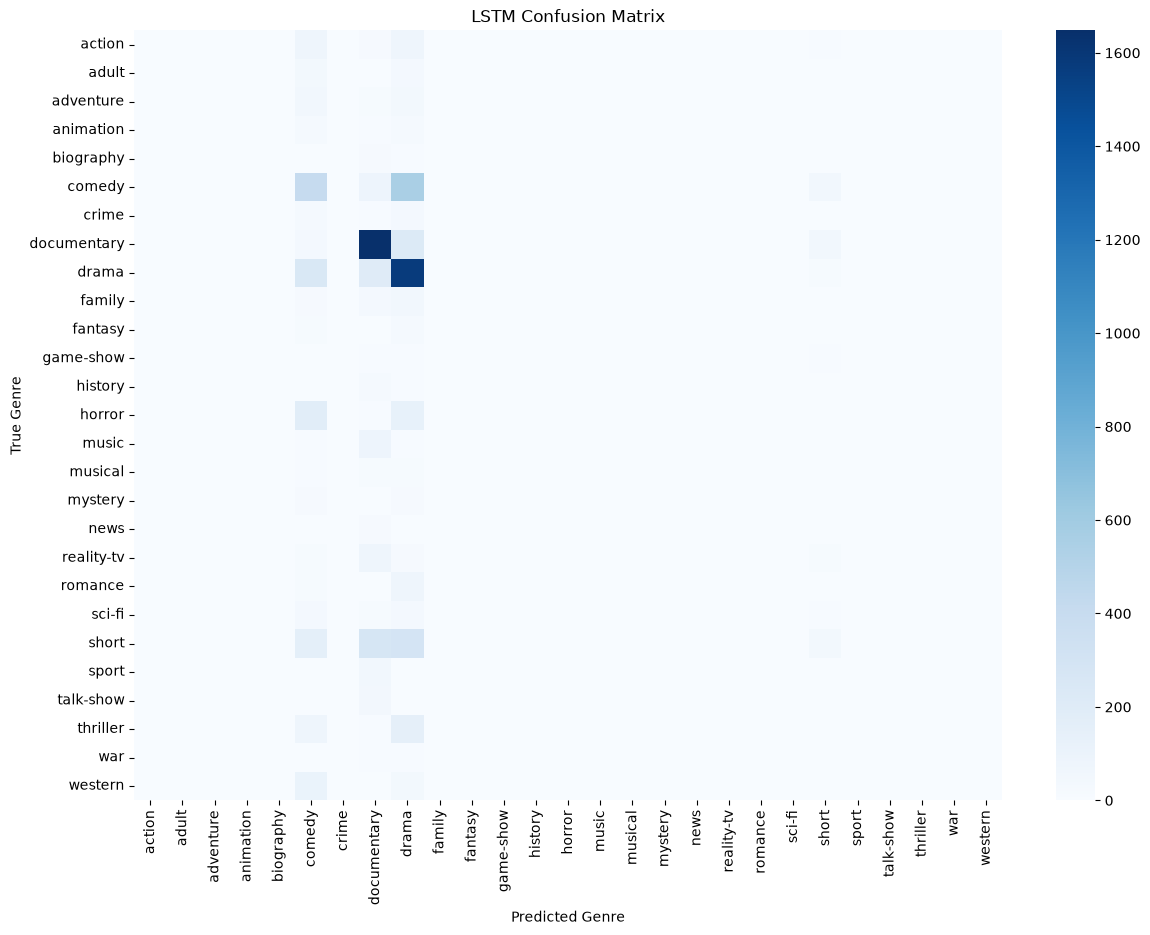

In [28]:
from sklearn.metrics import confusion_matrix

cm_lstm = confusion_matrix(
    test_metrics_lstm['labels'],
    test_metrics_lstm['preds']
)
# Считаем матрицу ошибок:
# строки — реальные жанры,
# столбцы — предсказанные жанры.

plt.figure(figsize=(14, 10))
# Задаем размер графика

sns.heatmap(
    cm_lstm,
    annot=False,
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
# Рисуем тепловую карту матрицы ошибок
# Чем темнее ячейка, тем больше объектов попало в эту пару true/predicted

plt.title('LSTM Confusion Matrix')

plt.xlabel('Predicted Genre')

plt.ylabel('True Genre')

plt.xticks(rotation=90)

plt.yticks(rotation=0)

plt.show()

LSTM-модель была обучена на токенизированных описаниях фильмов. На тестовой выборке получены метрики: accuracy = 0.4408, weighted F1 = 0.3569, macro F1 = 0.0618. 
Модель лучше всего распознает наиболее частые классы: documentary, drama и comedy. При этом редкие жанры почти не определяются, что видно по classification_report и confusion matrix. 
Основная причина такого результата — сильный дисбаланс классов и простая архитектура LSTM без предобученных эмбеддингов. Поэтому LSTM можно использовать как базовую RNN-модель для сравнения, но ожидать от нее высокого качества на всех 27 жанрах не стоит.

In [29]:
# Эксперимент с гиперпараметром hidden_dim для LSTM
# Проверяем, как размер скрытого состояния LSTM влияет на качество модели

import copy

hidden_dim_values = [64, 128, 256]
# Проверяем три значения hidden_dim:
# 64  — менее емкая модель;
# 128 — значение, которое использовалось в основной LSTM;
# 256 — более емкая модель.

lstm_hyperparam_results = []
# Сюда будем сохранять результаты экспериментов

for hidden_dim in hidden_dim_values:
    print(f'\nTraining LSTM with hidden_dim={hidden_dim}')

    experiment_model = LSTMClassifier(
        vocab_size=vocab_size,
        embedding_dim=128,
        hidden_dim=hidden_dim,
        output_dim=num_classes,
        num_layers=1,
        dropout=0.3
    ).to(device)
    # Создаем новую LSTM-модель с текущим значением hidden_dim

    experiment_criterion = nn.CrossEntropyLoss()
    # Используем ту же функцию потерь для многоклассовой классификации

    experiment_optimizer = torch.optim.Adam(
        experiment_model.parameters(),
        lr=1e-3
    )
    # Используем одинаковый optimizer и learning rate,
    # чтобы сравнивать именно влияние hidden_dim

    best_experiment_f1 = 0
    best_experiment_state = None

    for epoch in range(3):
        # Для эксперимента 3 эпох,
        # чтобы сравнить направления изменения качества

        train_loss, train_accuracy = train_one_epoch(
            experiment_model,
            train_loader_lstm,
            experiment_criterion,
            experiment_optimizer,
            device
        )

        val_metrics = evaluate_lstm(
            experiment_model,
            val_loader_lstm,
            experiment_criterion,
            device
        )

        print(
            f"hidden_dim={hidden_dim} | "
            f"Epoch [{epoch + 1}/3] | "
            f"Train loss: {train_loss:.4f} | "
            f"Train acc: {train_accuracy:.4f} | "
            f"Val F1 weighted: {val_metrics['f1_weighted']:.4f} | "
            f"Val F1 macro: {val_metrics['f1_macro']:.4f}"
        )

        if val_metrics['f1_weighted'] > best_experiment_f1:
            best_experiment_f1 = val_metrics['f1_weighted']
            best_experiment_state = copy.deepcopy(experiment_model.state_dict())
            # Сохраняем лучшую модель для текущего hidden_dim

    experiment_model.load_state_dict(best_experiment_state)
    # Загружаем лучшие веса для текущего значения hidden_dim

    test_metrics = evaluate_lstm(
        experiment_model,
        test_loader_lstm,
        experiment_criterion,
        device
    )
    # Проверяем лучшую модель на test-части

    lstm_hyperparam_results.append({
        'model': 'LSTM',
        'hidden_dim': hidden_dim,
        'test_accuracy': test_metrics['accuracy'],
        'test_precision_weighted': test_metrics['precision'],
        'test_recall_weighted': test_metrics['recall'],
        'test_f1_weighted': test_metrics['f1_weighted'],
        'test_f1_macro': test_metrics['f1_macro']
    })
    # Сохраняем итоговые test-метрики


Training LSTM with hidden_dim=64
hidden_dim=64 | Epoch [1/3] | Train loss: 2.4025 | Train acc: 0.2476 | Val F1 weighted: 0.1134 | Val F1 macro: 0.0173
hidden_dim=64 | Epoch [2/3] | Train loss: 2.2364 | Train acc: 0.3557 | Val F1 weighted: 0.2792 | Val F1 macro: 0.0421
hidden_dim=64 | Epoch [3/3] | Train loss: 2.0513 | Train acc: 0.4268 | Val F1 weighted: 0.3335 | Val F1 macro: 0.0550

Training LSTM with hidden_dim=128
hidden_dim=128 | Epoch [1/3] | Train loss: 2.3849 | Train acc: 0.2485 | Val F1 weighted: 0.2168 | Val F1 macro: 0.0326
hidden_dim=128 | Epoch [2/3] | Train loss: 2.1199 | Train acc: 0.4047 | Val F1 weighted: 0.2916 | Val F1 macro: 0.0440
hidden_dim=128 | Epoch [3/3] | Train loss: 1.9039 | Train acc: 0.4605 | Val F1 weighted: 0.3671 | Val F1 macro: 0.0619

Training LSTM with hidden_dim=256
hidden_dim=256 | Epoch [1/3] | Train loss: 2.3463 | Train acc: 0.2812 | Val F1 weighted: 0.2622 | Val F1 macro: 0.0395
hidden_dim=256 | Epoch [2/3] | Train loss: 2.1163 | Train acc: 0.4

In [30]:
lstm_hyperparam_results_df = pd.DataFrame(lstm_hyperparam_results)

lstm_hyperparam_results_df

,model,hidden_dim,test_accuracy,test_precision_weighted,test_recall_weighted,test_f1_weighted,test_f1_macro
0,LSTM,64,0.438461,0.287625,0.438461,0.336894,0.055808
1,LSTM,128,0.458502,0.331250,0.458502,0.366412,0.061901
2,LSTM,256,0.445100,0.320043,0.445100,0.339502,0.061577


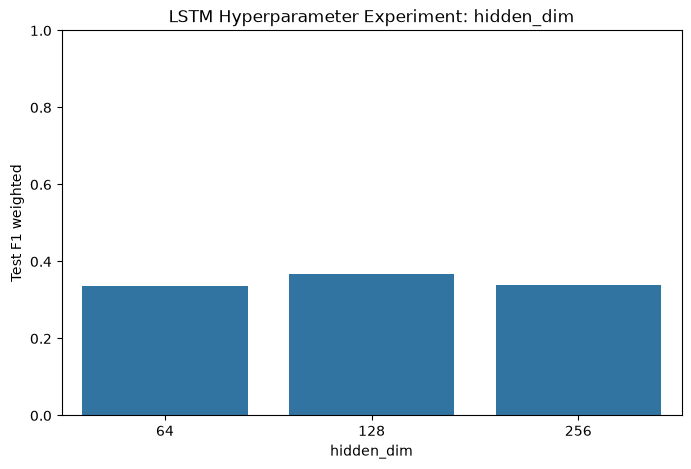

In [31]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=lstm_hyperparam_results_df,
    x='hidden_dim',
    y='test_f1_weighted'
)

plt.title('LSTM Hyperparameter Experiment: hidden_dim')
plt.xlabel('hidden_dim')
plt.ylabel('Test F1 weighted')
plt.ylim(0, 1)
plt.show()

Дополнительно был проведен эксперимент с гиперпараметром hidden_dim для LSTM-модели. 
Этот параметр отвечает за размер скрытого состояния LSTM: чем он больше, тем больше информации модель может хранить о последовательности, но при этом увеличивается число параметров и риск переобучения.

Были проверены три значения: 64, 128 и 256. 
Лучший результат на тестовой выборке показала модель с hidden_dim = 128: accuracy = 0.45, weighted F1 = 0.36, macro F1 = 0.06. 
При hidden_dim = 64 модель оказалась менее емкой и дала более низкое качество: weighted F1 = 0.33. 
При увеличении hidden_dim до 256 качество также не улучшилось: weighted F1 = 0.33, что может говорить о том, что простое увеличение размера скрытого состояния не решает проблему дисбаланса классов и ограниченности LSTM-подхода.

По итогам эксперимента значение hidden_dim = 128 выбрано как наиболее удачное среди проверенных. 
Однако даже после подбора гиперпараметра LSTM заметно уступает DistilBERT, который показал weighted F1 = 0.65 и macro F1 = 0.44. 
Это связано с тем, что DistilBERT использует предобученные языковые представления и лучше учитывает контекст описаний фильмов, тогда как LSTM обучается с нуля на текущем датасете.

### DistilBERT

In [32]:
!pip install -q transformers

In [33]:
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification
from torch.optim import AdamW
from tqdm.auto import tqdm

In [34]:
# Загружаем tokenizer
MODEL_NAME = 'distilbert-base-uncased'

tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)

In [35]:
# Dataset Для DistilBERT
class MovieGenreBertDataset(Dataset):
    # Создаем собственный Dataset для работы с DistilBERT

    def __init__(self, dataframe, tokenizer, max_len=128):
        # Конструктор получает датафрейм, tokenizer и максимальную длину текста

        self.texts = dataframe['full_text'].values
        # Сохраняем тексты, которые будем подавать в DistilBERT

        self.labels = dataframe['label'].values
        # Сохраняем числовые метки жанров

        self.tokenizer = tokenizer
        # Сохраняем tokenizer DistilBERT
        # Он будет переводить текст в формат, понятный модели

        self.max_len = max_len
        # Сохраняем максимальную длину последовательности токенов

    def __len__(self):
        # Метод возвращает количество объектов в датасете

        return len(self.texts)
        # Длина датасета равна количеству текстов

    def __getitem__(self, idx):
        # Метод возвращает один объект по индексу idx

        text = str(self.texts[idx])
        # Берем текст по индексу и приводим его к строке

        label = int(self.labels[idx])
        # Берем правильную метку класса и приводим ее к int

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt'
        )
        # Токенизируем текст:
        # truncation=True обрезает слишком длинные тексты;
        # padding='max_length' дополняет короткие тексты до max_len;
        # max_length задает итоговую длину последовательности;
        # return_tensors='pt' возвращает результат в формате PyTorch Tensor.

        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'label': torch.tensor(label, dtype=torch.long)
        }
        # Возвращаем словарь:
        # input_ids — индексы токенов;
        # attention_mask — маска реальных токенов и padding;
        # label — правильный класс.

In [36]:
# DataLoader Для DistilBERT
BERT_MAX_LEN = 128
# Максимальная длина текста после токенизации

BERT_BATCH_SIZE = 16
# Размер батча для DistilBERT
# Трансформеры тяжелее LSTM, поэтому batch обычно меньше

train_dataset_bert = MovieGenreBertDataset(
    train_df,
    tokenizer,
    max_len=BERT_MAX_LEN
)
# Создаем Dataset для обучающей выборки

val_dataset_bert = MovieGenreBertDataset(
    val_df,
    tokenizer,
    max_len=BERT_MAX_LEN
)
# Создаем Dataset для validation-выборки

test_dataset_bert = MovieGenreBertDataset(
    test_df_labeled,
    tokenizer,
    max_len=BERT_MAX_LEN
)
# Создаем Dataset для test-выборки

train_loader_bert = DataLoader(
    train_dataset_bert,
    batch_size=BERT_BATCH_SIZE,
    shuffle=True
)
# DataLoader для обучения
# shuffle=True перемешивает тексты перед каждой эпохой

val_loader_bert = DataLoader(
    val_dataset_bert,
    batch_size=BERT_BATCH_SIZE,
    shuffle=False
)
# DataLoader для validation
# Перемешивание не нужно, потому что модель только оценивается

test_loader_bert = DataLoader(
    test_dataset_bert,
    batch_size=BERT_BATCH_SIZE,
    shuffle=False
)
# DataLoader для test
# Перемешивание также не нужно

In [37]:
# Создаем Модель
bert_model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_classes
)
# Загружаем предобученную DistilBERT-модель
# num_labels=num_classes заменяет классификационную голову под наши 27 жанров

bert_model = bert_model.to(device)
# Переносим модель на GPU, если он доступен, иначе на CPU

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [38]:
bert_optimizer = AdamW(
    bert_model.parameters(),
    lr=2e-5
)
# Создаем оптимизатор AdamW для обучения DistilBERT
# В него передаем все параметры модели
# lr=2e-5 — типичная небольшая скорость обучения для fine-tuning трансформеров

In [39]:
# Функция Обучения DistilBERT
def train_bert_one_epoch(model, dataloader, optimizer, device):
    # Функция обучает DistilBERT одну эпоху

    model.train()
    # Переводим модель в режим обучения

    total_loss = 0
    # Здесь будем накапливать loss по батчам

    correct = 0
    # Количество правильных предсказаний

    total = 0
    # Общее количество объектов

    for batch in tqdm(dataloader):
        # Проходим по батчам train_loader_bert

        input_ids = batch['input_ids'].to(device)
        # Индексы токенов переносим на CPU/GPU

        attention_mask = batch['attention_mask'].to(device)
        # Маску внимания переносим на CPU/GPU
        # Она показывает модели, где реальные токены, а где padding

        labels = batch['label'].to(device)
        # Правильные метки классов переносим на CPU/GPU

        optimizer.zero_grad()
        # Обнуляем градиенты с предыдущего шага

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )
        # Прогоняем батч через DistilBERT
        # Если передать labels, модель сама посчитает loss

        loss = outputs.loss
        # Забираем loss из результата модели

        logits = outputs.logits
        # Забираем logits — сырые предсказания по 27 классам

        loss.backward()
        # Считаем градиенты

        optimizer.step()
        # Обновляем веса модели

        total_loss += loss.item()
        # Добавляем loss текущего батча

        _, preds = torch.max(logits, dim=1)
        # Выбираем класс с максимальным logit

        correct += (preds == labels).sum().item()
        # Считаем правильные ответы

        total += labels.size(0)
        # Увеличиваем счетчик объектов

    avg_loss = total_loss / len(dataloader)
    # Средний loss за эпоху

    accuracy = correct / total
    # Accuracy за эпоху

    return avg_loss, accuracy
    # Возвращаем loss и accuracy

In [40]:
# Функция Оценки DistilBERT 
def evaluate_bert(model, dataloader, device):
    # Функция оценивает DistilBERT на validation или test

    model.eval()
    # Переводим модель в режим оценки

    total_loss = 0
    # Здесь будем накапливать loss

    all_labels = []
    # Истинные метки

    all_preds = []
    # Предсказанные классы

    with torch.no_grad():
        # Отключаем расчет градиентов

        for batch in tqdm(dataloader):
            # Проходим по батчам

            input_ids = batch['input_ids'].to(device)
            # Переносим input_ids на CPU/GPU

            attention_mask = batch['attention_mask'].to(device)
            # Переносим attention_mask на CPU/GPU

            labels = batch['label'].to(device)
            # Переносим правильные метки

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )
            # Получаем выход модели и loss

            loss = outputs.loss
            # Loss на батче

            logits = outputs.logits
            # Logits по всем классам

            total_loss += loss.item()
            # Накопление loss

            _, preds = torch.max(logits, dim=1)
            # Предсказанный класс

            all_labels.extend(labels.cpu().numpy())
            # Сохраняем реальные метки

            all_preds.extend(preds.cpu().numpy())
            # Сохраняем предсказания

    avg_loss = total_loss / len(dataloader)

    accuracy = accuracy_score(all_labels, all_preds)

    precision = precision_score(
        all_labels,
        all_preds,
        average='weighted',
        zero_division=0
    )
    # Weighted precision

    recall = recall_score(
        all_labels,
        all_preds,
        average='weighted',
        zero_division=0
    )
    # Weighted recall

    f1_weighted = f1_score(
        all_labels,
        all_preds,
        average='weighted',
        zero_division=0
    )
    # Weighted F1

    f1_macro = f1_score(
        all_labels,
        all_preds,
        average='macro',
        zero_division=0
    )
    # Macro F1

    return {
        'loss': avg_loss,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_weighted': f1_weighted,
        'f1_macro': f1_macro,
        'labels': all_labels,
        'preds': all_preds
    }
    # Возвращаем метрики и предсказания

In [41]:
# Обучение DistilBERT
BERT_NUM_EPOCHS = 2
# Для DistilBERT обычно достаточно 2-3 эпох
# На CPU обучение может быть долгим

bert_train_losses = []
# Loss на train

bert_val_losses = []
# Loss на validation

bert_train_accuracies = []
# Accuracy на train

bert_val_accuracies = []
# Accuracy на validation

best_bert_f1 = 0
# Лучший validation F1

best_bert_state = None
# Веса лучшей модели

for epoch in range(BERT_NUM_EPOCHS):
    # Цикл по эпохам

    train_loss, train_acc = train_bert_one_epoch(
        bert_model,
        train_loader_bert,
        bert_optimizer,
        device
    )
    # Обучаем одну эпоху

    val_metrics_bert = evaluate_bert(
        bert_model,
        val_loader_bert,
        device
    )
    # Оцениваем на validation

    bert_train_losses.append(train_loss)
    # Сохраняем train loss

    bert_val_losses.append(val_metrics_bert['loss'])
    # Сохраняем validation loss

    bert_train_accuracies.append(train_acc)
    # Сохраняем train accuracy

    bert_val_accuracies.append(val_metrics_bert['accuracy'])
    # Сохраняем validation accuracy

    print(
        f"Epoch [{epoch + 1}/{BERT_NUM_EPOCHS}] | "
        f"Train loss: {train_loss:.4f} | "
        f"Train acc: {train_acc:.4f} | "
        f"Val loss: {val_metrics_bert['loss']:.4f} | "
        f"Val acc: {val_metrics_bert['accuracy']:.4f} | "
        f"Val F1 weighted: {val_metrics_bert['f1_weighted']:.4f} | "
        f"Val F1 macro: {val_metrics_bert['f1_macro']:.4f}"
    )

    if val_metrics_bert['f1_weighted'] > best_bert_f1:
        # Если текущая модель лучше предыдущей,

        best_bert_f1 = val_metrics_bert['f1_weighted']
        # обновляем лучший F1

        best_bert_state = bert_model.state_dict()
        # сохраняем веса модели

  0%|          | 0/2372 [00:00<?, ?it/s]

  0%|          | 0/509 [00:00<?, ?it/s]

Epoch [1/2] | Train loss: 1.4027 | Train acc: 0.5936 | Val loss: 1.1148 | Val acc: 0.6571 | Val F1 weighted: 0.6340 | Val F1 macro: 0.3861


  0%|          | 0/2372 [00:00<?, ?it/s]

  0%|          | 0/509 [00:00<?, ?it/s]

Epoch [2/2] | Train loss: 0.9548 | Train acc: 0.7106 | Val loss: 1.0594 | Val acc: 0.6732 | Val F1 weighted: 0.6584 | Val F1 macro: 0.4543


In [42]:
bert_model.load_state_dict(best_bert_state)

<All keys matched successfully>

лучшие веса модели успешно загрузились

In [43]:
# делаем финальную оценку DistilBERT на test-части
test_metrics_bert = evaluate_bert(
    bert_model,
    test_loader_bert,
    device
)

print('DistilBERT test metrics:')
print(f"Accuracy: {test_metrics_bert['accuracy']:.4f}")
print(f"Precision weighted: {test_metrics_bert['precision']:.4f}")
print(f"Recall weighted: {test_metrics_bert['recall']:.4f}")
print(f"F1 weighted: {test_metrics_bert['f1_weighted']:.4f}")
print(f"F1 macro: {test_metrics_bert['f1_macro']:.4f}")

  0%|          | 0/509 [00:00<?, ?it/s]

DistilBERT test metrics:
Accuracy: 0.6712
Precision weighted: 0.6546
Recall weighted: 0.6712
F1 weighted: 0.6571
F1 macro: 0.4475


In [44]:
print(
    classification_report(
        test_metrics_bert['labels'],
        test_metrics_bert['preds'],
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

              precision    recall  f1-score   support

      action       0.51      0.49      0.50       197
       adult       0.56      0.65      0.60        88
   adventure       0.39      0.42      0.40       116
   animation       0.41      0.35      0.38        75
   biography       0.00      0.00      0.00        40
      comedy       0.66      0.64      0.65      1117
       crime       0.44      0.14      0.22        76
 documentary       0.81      0.87      0.84      1965
       drama       0.68      0.74      0.71      2042
      family       0.45      0.26      0.33       117
     fantasy       0.44      0.17      0.24        48
   game-show       0.84      0.72      0.78        29
     history       0.00      0.00      0.00        36
      horror       0.66      0.78      0.72       331
       music       0.72      0.62      0.67       110
     musical       0.38      0.22      0.28        41
     mystery       0.50      0.02      0.04        48
        news       0.60    

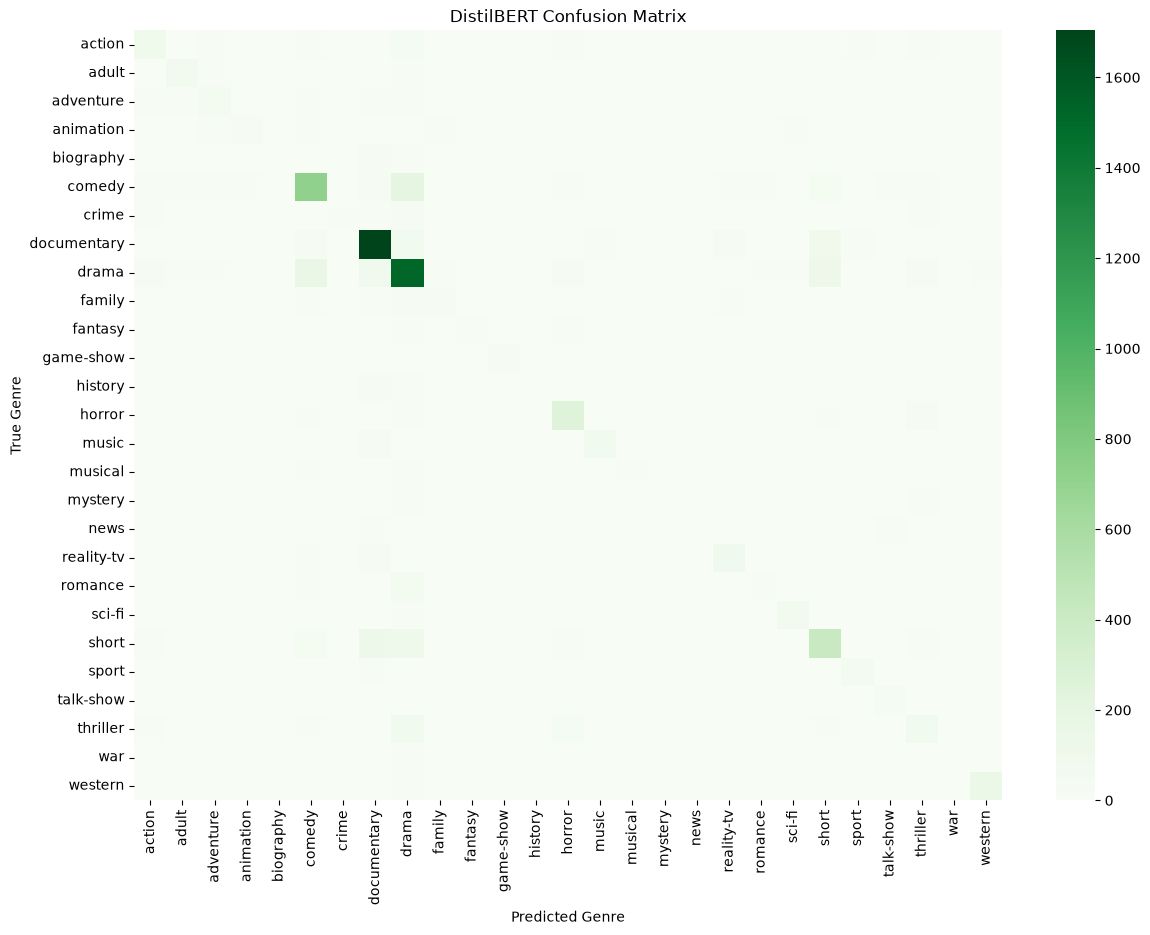

In [45]:
cm_bert = confusion_matrix(
    test_metrics_bert['labels'],
    test_metrics_bert['preds']
)

plt.figure(figsize=(14, 10))

sns.heatmap(
    cm_bert,
    annot=False,
    cmap='Greens',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title('DistilBERT Confusion Matrix')
plt.xlabel('Predicted Genre')
plt.ylabel('True Genre')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

Модель DistilBERT показала значительно более высокое качество по сравнению с LSTM. 
На тестовой выборке получены метрики: accuracy = 0.6712, weighted F1 = 0.6518, macro F1 = 0.4421. 
Это заметно выше результатов LSTM, у которой weighted F1 был около 0.3569, а macro F1 — около 0.0618.

DistilBERT лучше справляется не только с частыми классами, но и с частью редких жанров. 
Например, хорошие значения F1 получились для documentary, drama, horror, comedy, music, sport, game-show и western. 
При этом часть редких и близких по смыслу классов всё ещё распознается слабо: biography, history, mystery, news, romance. 
Это связано с сильным дисбалансом классов и смысловой близостью некоторых жанров.

Лучшей моделью оказалась DistilBERT. Она использует предобученные языковые представления и поэтому лучше понимает контекст описаний фильмов. LSTM обучалась с нуля на текущем датасете и в основном научилась предсказывать самые частые жанры. 
Однако даже DistilBERT хуже работает с редкими жанрами, поэтому для дальнейшего улучшения можно использовать балансировку классов, class weights, увеличение числа эпох, подбор max_length и learning rate.

Матрица ошибок показывает, что основные предсказания сосредоточены вокруг наиболее частых жанров: documentary, drama, comedy, short и horror. 
Часть ошибок возникает между близкими жанрами, например drama/romance, horror/thriller, action/adventure. 
Редкие классы имеют мало примеров, поэтому модель хуже выделяет их как отдельные категории.